In [ ]:
"""
MobileNetV3-Large fine-tuning baseline on HAM10000 — matched to the DINOv2 run.

Same splits (loaded from splits.csv), same colour constancy, same weight cap,
same label smoothing, same eval. The ONLY variable is the model, so the
comparison is honest.

Colab, GPU runtime. Paste into cells at the CELL markers.

Note on the recipe: this is a *proper* MobileNet fine-tune, not the one from
the blueprint. Differences that matter:
  - keeps the 1280-unit hidden layer (blueprint's Linear(960,7) throws it away)
  - unfreezes the WHOLE backbone in stage 2, not the last 2 blocks
    (dermoscopy is far from ImageNet; partial unfreezing underfits badly)
  - weight cap 2.0, matching what the DINOv2 sweep found optimal
"""

In [1]:

# ============================================================ CELL 1: setup
import os, glob, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import kagglehub
DATA = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("dataset:", DATA)

SEED = 42
OUT = "/content/drive/MyDrive/amsdds"
CACHE = "/content/ham_cache"          # LOCAL disk — Drive is far too slow for
os.makedirs(OUT, exist_ok=True)       # thousands of small image reads
os.makedirs(CACHE, exist_ok=True)

IMG_SIZE = 224
BATCH = 32
WEIGHT_CAP = 2.0
USE_COLOR_CONSTANCY = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED); np.random.seed(SEED)
print("device:", DEVICE)


Mounted at /content/drive
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
dataset: /kaggle/input/skin-cancer-mnist-ham10000
device: cuda


In [2]:

# ============================================ CELL 2: reuse the SAME splits
src = {os.path.splitext(os.path.basename(p))[0]: p
       for p in glob.glob(f"{DATA}/**/*.jpg", recursive=True)}

splits_csv = f"{OUT}/splits.csv"
if os.path.exists(splits_csv):
    df = pd.read_csv(splits_csv)
    print("loaded existing splits — comparison is apples-to-apples")
else:
    from sklearn.model_selection import StratifiedGroupKFold
    meta = glob.glob(f"{DATA}/**/HAM10000_metadata*.csv", recursive=True)[0]
    df = pd.read_csv(meta)
    df["y"] = df.dx.map({c: i for i, c in enumerate(sorted(df.dx.unique()))})
    sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    fold = np.zeros(len(df), dtype=int)
    for f, (_, idx) in enumerate(sgkf.split(df, df.y, groups=df.lesion_id)):
        fold[idx] = f
    df["split"] = np.where(fold == 0, "test", np.where(fold == 1, "val", "train"))
    df.to_csv(splits_csv, index=False)
    print("regenerated splits")

CLASSES = sorted(df.dx.unique())
df["y"] = df.dx.map({c: i for i, c in enumerate(CLASSES)})
df["src"] = df.image_id.map(src)
df["path"] = df.image_id.map(lambda i: f"{CACHE}/{i}.jpg")
assert df.src.isna().sum() == 0, "some images not found"
print(df.split.value_counts().to_dict())



loaded existing splits — comparison is apples-to-apples
{'train': 7116, 'val': 1458, 'test': 1441}


In [3]:

# ================================ CELL 3: one-time preprocessed image cache
# Colour constancy + resize done ONCE to local disk. Without this, every epoch
# redoes the numpy power ops on 600x450 images and the CPU starves the GPU.
def shades_of_gray(arr, power=6):
    a = arr.astype(np.float32)
    vec = np.power(np.mean(np.power(a, power), axis=(0, 1)), 1.0 / power)
    vec = vec / (np.sqrt(np.sum(vec ** 2)) + 1e-8)
    return np.clip(a / (vec * np.sqrt(3) + 1e-8), 0, 255).astype(np.uint8)


def build_one(row):
    dst = row.path
    if os.path.exists(dst):
        return
    img = Image.open(row.src).convert("RGB")
    w, h = img.size
    s = 256 / min(w, h)
    img = img.resize((round(w * s), round(h * s)), Image.BICUBIC)
    if USE_COLOR_CONSTANCY:
        img = Image.fromarray(shades_of_gray(np.array(img)))
    img.save(dst, quality=95)


need = sum(not os.path.exists(p) for p in df.path)
if need:
    from concurrent.futures import ThreadPoolExecutor
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex:
        list(ex.map(build_one, [r for r in df.itertuples()]))
    print(f"cached {need} images in {time.time()-t0:.0f}s")
else:
    print("image cache already built")



cached 10015 images in 151s


In [4]:

# ============================================ CELL 4: datasets + transforms
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.85, 1.18)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation(30)], p=0.5),
    T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.03),
    T.RandomApply([T.GaussianBlur(5, sigma=(0.1, 1.5))], p=0.25),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
eval_tf = T.Compose([
    T.Resize(256), T.CenterCrop(IMG_SIZE),
    T.ToTensor(), T.Normalize(MEAN, STD),
])


class HAM(Dataset):
    def __init__(self, frame, tf):
        self.f = frame.reset_index(drop=True); self.tf = tf

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        return self.tf(Image.open(r.path).convert("RGB")), int(r.y)


tr, va, te = (df[df.split == s] for s in ("train", "val", "test"))
dl_tr = DataLoader(HAM(tr, train_tf), BATCH, shuffle=True, num_workers=4,
                   pin_memory=True, drop_last=True, persistent_workers=True)
dl_va = DataLoader(HAM(va, eval_tf), 64, num_workers=4, pin_memory=True)
dl_te = DataLoader(HAM(te, eval_tf), 64, num_workers=4, pin_memory=True)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [5]:

# ==================================================== CELL 5: model + loss
model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
# keep the 1280 hidden layer, swap only the final projection
model.classifier[3] = nn.Linear(1280, len(CLASSES))
model = model.to(DEVICE)

counts = np.bincount(tr.y.values, minlength=len(CLASSES)).astype(np.float32)
w = 1.0 / np.sqrt(counts)
w = np.clip(w / w.min(), 1.0, WEIGHT_CAP)
print("class weights:", dict(zip(CLASSES, np.round(w, 2))))
lossfn = nn.CrossEntropyLoss(weight=torch.tensor(w).to(DEVICE), label_smoothing=0.05)

scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")
from sklearn.metrics import f1_score


@torch.no_grad()
def evaluate(loader, return_logits=False):
    model.eval()
    L, Y = [], []
    for x, y in loader:
        with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
            L.append(model(x.to(DEVICE)).float().cpu())
        Y.append(y)
    L, Y = torch.cat(L), torch.cat(Y)
    f1 = f1_score(Y.numpy(), L.argmax(1).numpy(), average="macro")
    return (f1, L, Y) if return_logits else f1


def run_epochs(n, opt, sched, tag):
    global best_f1, best_state
    for ep in range(n):
        model.train(); t0 = time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
                loss = lossfn(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        f1 = evaluate(dl_va)
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"{tag} ep {ep:2d}  val macro-F1 {f1:.4f}  ({time.time()-t0:.0f}s)")



Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 50.0MB/s]


class weights: {'akiec': np.float32(2.0), 'bcc': np.float32(2.0), 'bkl': np.float32(2.0), 'df': np.float32(2.0), 'mel': np.float32(2.0), 'nv': np.float32(1.0), 'vasc': np.float32(2.0)}


In [6]:

# ============================================== CELL 6: two-stage fine-tune
best_f1, best_state = -1, None

# Stage 1 — frozen backbone, classifier only
for p in model.features.parameters():
    p.requires_grad_(False)
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
run_epochs(5, opt, torch.optim.lr_scheduler.CosineAnnealingLR(opt, 5), "S1")

# Stage 2 — unfreeze EVERYTHING, low LR on the backbone
for p in model.features.parameters():
    p.requires_grad_(True)
EPOCHS2 = 25
opt = torch.optim.AdamW([
    {"params": model.features.parameters(),   "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 5e-4},
], weight_decay=1e-4)
run_epochs(EPOCHS2, opt, torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS2), "S2")

model.load_state_dict(best_state)
print(f"\nbest val macro-F1 {best_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S1 ep  0  val macro-F1 0.4646  (87s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S1 ep  1  val macro-F1 0.5465  (71s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

S2 ep 22  val macro-F1 0.6964  (73s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S2 ep 23  val macro-F1 0.7097  (74s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S2 ep 24  val macro-F1 0.7106  (75s)

best val macro-F1 0.7152


In [7]:

# ============================== CELL 7: temperature scaling + test evaluation
_, lv, yv = evaluate(dl_va, return_logits=True)
lv, yv = lv.to(DEVICE), yv.to(DEVICE)
logT = torch.zeros(1, device=DEVICE, requires_grad=True)
topt = torch.optim.LBFGS([logT], lr=0.1, max_iter=60)


def _closure():
    topt.zero_grad()
    l = F.cross_entropy(lv / logT.exp(), yv); l.backward(); return l


topt.step(_closure)
TEMP = float(logT.exp())
print(f"fitted temperature T = {TEMP:.3f}")


def ece(probs, labels, bins=15):
    conf, pred = probs.max(1), probs.argmax(1)
    acc = (pred == labels).astype(np.float32)
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

_, lt, yt = evaluate(dl_te, return_logits=True)
yt = yt.numpy()
p_raw = F.softmax(lt, 1).numpy()
p_cal = F.softmax(lt / TEMP, 1).numpy()
pred = p_cal.argmax(1)

MB = {"test_acc": accuracy_score(yt, pred),
      "test_macro_f1": f1_score(yt, pred, average="macro"),
      "ece_raw": ece(p_raw, yt), "ece_cal": ece(p_cal, yt),
      "val_macro_f1": best_f1, "temperature": TEMP}

print(f"\ntest accuracy   {MB['test_acc']:.4f}")
print(f"test macro-F1   {MB['test_macro_f1']:.4f}")
print(f"ECE  raw {MB['ece_raw']:.4f}  ->  calibrated {MB['ece_cal']:.4f}")
print("\n", classification_report(yt, pred, target_names=CLASSES, digits=3))
print(pd.DataFrame(confusion_matrix(yt, pred), index=CLASSES, columns=CLASSES))

torch.save({"state": best_state, "classes": CLASSES, "temperature": TEMP,
            "img_size": IMG_SIZE, "color_constancy": USE_COLOR_CONSTANCY,
            "weight_cap": WEIGHT_CAP, "metrics": MB},
           f"{OUT}/baseline_mobilenetv3.pt")
json.dump({k: float(v) for k, v in MB.items()},
          open(f"{OUT}/metrics_mobilenetv3.json", "w"), indent=2)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


fitted temperature T = 0.972


/tmp/ipykernel_1006/3923385412.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  TEMP = float(logT.exp())
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



test accuracy   0.8446
test macro-F1   0.7059
ECE  raw 0.0289  ->  calibrated 0.0249

               precision    recall  f1-score   support

       akiec      0.533     0.471     0.500        34
         bcc      0.819     0.764     0.791        89
         bkl      0.698     0.714     0.706       168
          df      0.800     0.444     0.571         9
         mel      0.569     0.534     0.551       146
          nv      0.917     0.938     0.927       974
        vasc      1.000     0.810     0.895        21

    accuracy                          0.845      1441
   macro avg      0.762     0.668     0.706      1441
weighted avg      0.841     0.845     0.842      1441

       akiec  bcc  bkl  df  mel   nv  vasc
akiec     16    5    5   0    6    2     0
bcc        3   68    5   0    6    7     0
bkl        8    2  120   0   12   26     0
df         1    2    0   4    0    2     0
mel        0    5   17   1   78   45     0
nv         2    1   25   0   32  914     0
vasc       0  

In [8]:

# ================================================ CELL 8: side-by-side table
DINO = {"test_acc": 0.8119, "test_macro_f1": 0.6387,
        "ece_raw": 0.0251, "ece_cal": 0.0183, "val_macro_f1": 0.7174}

cmp = pd.DataFrame({
    "MobileNetV3 (fine-tuned)": [MB["test_acc"], MB["test_macro_f1"],
                                 MB["ece_raw"], MB["ece_cal"], MB["val_macro_f1"]],
    "DINOv2 ViT-S (frozen+MLP)": [DINO["test_acc"], DINO["test_macro_f1"],
                                  DINO["ece_raw"], DINO["ece_cal"], DINO["val_macro_f1"]],
}, index=["test accuracy", "test macro-F1", "ECE raw", "ECE calibrated", "val macro-F1"])
print(cmp.round(4))
cmp.to_csv(f"{OUT}/layer1_comparison.csv")

# Per-class melanoma recall is the number that matters clinically — pull it out
mel_i = CLASSES.index("mel")
cm = confusion_matrix(yt, pred)
print(f"\nmelanoma recall: {cm[mel_i, mel_i] / cm[mel_i].sum():.3f}")
print(f"melanoma -> nv misses: {cm[mel_i, CLASSES.index('nv')]}")


                MobileNetV3 (fine-tuned)  DINOv2 ViT-S (frozen+MLP)
test accuracy                     0.8446                     0.8119
test macro-F1                     0.7059                     0.6387
ECE raw                           0.0289                     0.0251
ECE calibrated                    0.0249                     0.0183
val macro-F1                      0.7152                     0.7174

melanoma recall: 0.534
melanoma -> nv misses: 45


In [9]:
"""
Threshold sweep for the Adaptive Decision Engine (blueprint Section 8.3).

Run in the SAME notebook as the MobileNetV3 script — reuses model, dl_va,
dl_te, CLASSES, TEMP, OUT. If the runtime died, re-run its Cells 1-5 first
(the image cache is on local disk and rebuilds in a few minutes).

Sweeps on VAL only. Test is touched once at the end, for reporting.

The objective is NOT "escalation rate 20-35%". That is a compute-budget
constraint, not a goal. The goal is: of the malignant lesions Layer 1 calls
benign, how many does the gate catch and send to Layer 2? Those are the
failures that hurt someone.
"""


'\nThreshold sweep for the Adaptive Decision Engine (blueprint Section 8.3).\n \nRun in the SAME notebook as the MobileNetV3 script — reuses model, dl_va,\ndl_te, CLASSES, TEMP, OUT. If the runtime died, re-run its Cells 1-5 first\n(the image cache is on local disk and rebuilds in a few minutes).\n \nSweeps on VAL only. Test is touched once at the end, for reporting.\n \nThe objective is NOT "escalation rate 20-35%". That is a compute-budget\nconstraint, not a goal. The goal is: of the malignant lesions Layer 1 calls\nbenign, how many does the gate catch and send to Layer 2? Those are the\nfailures that hurt someone.\n'

In [10]:

# ==================================================== CELL A: get the logits
import numpy as np, pandas as pd, torch, torch.nn.functional as F, json, os

MALIGNANT = ["mel", "bcc", "akiec"]          # akiec = in-situ SCC, treat as concerning
BENIGN = [c for c in CLASSES if c not in MALIGNANT]
MAL_I = [CLASSES.index(c) for c in MALIGNANT]
BEN_I = [CLASSES.index(c) for c in BENIGN]
print("malignant:", MALIGNANT, "| benign:", BENIGN)


def logits_for(loader):
    _, L, Y = evaluate(loader, return_logits=True)
    return L, Y.numpy()


Lv, yv = logits_for(dl_va)
Lt, yt = logits_for(dl_te)


def conf_entropy(L, temp):
    """Calibrated confidence + entropy normalised by log(n_classes), so the
    threshold is a clean class-count-independent number in [0, 1]."""
    p = F.softmax(L / temp, dim=1).numpy()
    conf = p.max(1)
    ent = -(p * np.log(p + 1e-12)).sum(1) / np.log(len(CLASSES))
    return p, conf, ent


pv, cv, ev = conf_entropy(Lv, TEMP)
pt, ct, et = conf_entropy(Lt, TEMP)
predv, predt = pv.argmax(1), pt.argmax(1)

# A "dangerous miss": truly malignant, predicted benign.
dang_v = np.isin(yv, MAL_I) & np.isin(predv, BEN_I)
dang_t = np.isin(yt, MAL_I) & np.isin(predt, BEN_I)
print(f"val dangerous misses  {dang_v.sum()} / {np.isin(yv, MAL_I).sum()} malignant")
print(f"test dangerous misses {dang_t.sum()} / {np.isin(yt, MAL_I).sum()} malignant")



malignant: ['mel', 'bcc', 'akiec'] | benign: ['bkl', 'df', 'nv', 'vasc']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val dangerous misses  100 / 315 malignant
test dangerous misses 82 / 269 malignant


In [14]:

# ======================================================== CELL B: the sweep
def score(conf, ent, pred, y, dang, ct_, et_):
    accept = (conf >= ct_) & (ent <= et_)
    esc = ~accept
    n = len(y)
    return {
        "conf_thr": ct_, "entropy_thr": et_,
        "escalation_rate": esc.mean(),
        # accuracy on what we ship WITHOUT a second opinion
        "fastpath_acc": (pred[accept] == y[accept]).mean() if accept.sum() else np.nan,
        "fastpath_n": int(accept.sum()),
        # of all dangerous misses, what fraction get escalated (i.e. caught)
        "dang_caught": esc[dang].mean() if dang.sum() else np.nan,
        # dangerous misses that sail through the gate — the ones that hurt
        "dang_leaked": int((dang & accept).sum()),
        # sanity: is the escalated pile actually the hard pile?
        "esc_acc": (pred[esc] == y[esc]).mean() if esc.sum() else np.nan,
    }


rows = [score(cv, ev, predv, yv, dang_v, c, e)
        for c in np.arange(0.50, 0.96, 0.05)
        for e in np.arange(0.10, 0.61, 0.05)]
S = pd.DataFrame(rows)
S["conf_thr"] = S.conf_thr.round(2)
S["entropy_thr"] = S.entropy_thr.round(2)
# Constraints from the blueprint, then optimise for safety within them.
MIN_FASTPATH_ACC = 0.90
ESC_LO, ESC_HI = 0.20, 0.35

ok = S[(S.fastpath_acc >= MIN_FASTPATH_ACC) &
       (S.escalation_rate.between(ESC_LO, ESC_HI))]

if len(ok) == 0:
    print(f"\nNo pair satisfies acc>={MIN_FASTPATH_ACC} and "
          f"escalation in [{ESC_LO},{ESC_HI}]. Relaxing the escalation band.")
    ok = S[S.fastpath_acc >= MIN_FASTPATH_ACC]
if len(ok) == 0:
    print("\nStill nothing. Reporting the best fast-path accuracy available.")
    ok = S.nlargest(20, "fastpath_acc")

# maximise dangerous-miss capture; break ties toward LESS escalation
best = ok.sort_values(["dang_caught", "escalation_rate"],
                      ascending=[False, True]).iloc[0]

CONF_THRESHOLD = round(float(best.conf_thr), 2)
ENTROPY_THRESHOLD = round(float(best.entropy_thr), 2)
UNCERTAIN_FLOOR = 0.50

print(f"\n{'='*58}\nCHOSEN THRESHOLDS (val)")
print(f"  CONF_THRESHOLD     {CONF_THRESHOLD}")
print(f"  ENTROPY_THRESHOLD  {ENTROPY_THRESHOLD}")
print(f"{'='*58}")
print(f"  escalation rate    {best.escalation_rate:.1%}")
print(f"  fast-path accuracy {best.fastpath_acc:.1%}  (n={best.fastpath_n})")
print(f"  dangerous misses caught  {best.dang_caught:.1%}")
print(f"  dangerous misses leaked  {int(best.dang_leaked)}")
print(f"  accuracy on escalated pile {best.esc_acc:.1%}  "
      f"<- Layer 2 must beat this or escalation is dead weight")

print("\ntop 10 candidates:")
print(ok.sort_values(["dang_caught", "escalation_rate"], ascending=[False, True])
        .head(10).round(3).to_string(index=False))




CHOSEN THRESHOLDS (val)
  CONF_THRESHOLD     0.85
  ENTROPY_THRESHOLD  0.35
  escalation rate    32.9%
  fast-path accuracy 93.4%  (n=979.0)
  dangerous misses caught  62.0%
  dangerous misses leaked  38
  accuracy on escalated pile 62.4%  <- Layer 2 must beat this or escalation is dead weight

top 10 candidates:
 conf_thr  entropy_thr  escalation_rate  fastpath_acc  fastpath_n  dang_caught  dang_leaked  esc_acc
     0.85         0.35            0.329         0.934         979         0.62           38    0.624
     0.85         0.40            0.329         0.934         979         0.62           38    0.624
     0.85         0.45            0.329         0.934         979         0.62           38    0.624
     0.85         0.50            0.329         0.934         979         0.62           38    0.624
     0.85         0.55            0.329         0.934         979         0.62           38    0.624
     0.85         0.60            0.329         0.934         979         0.62

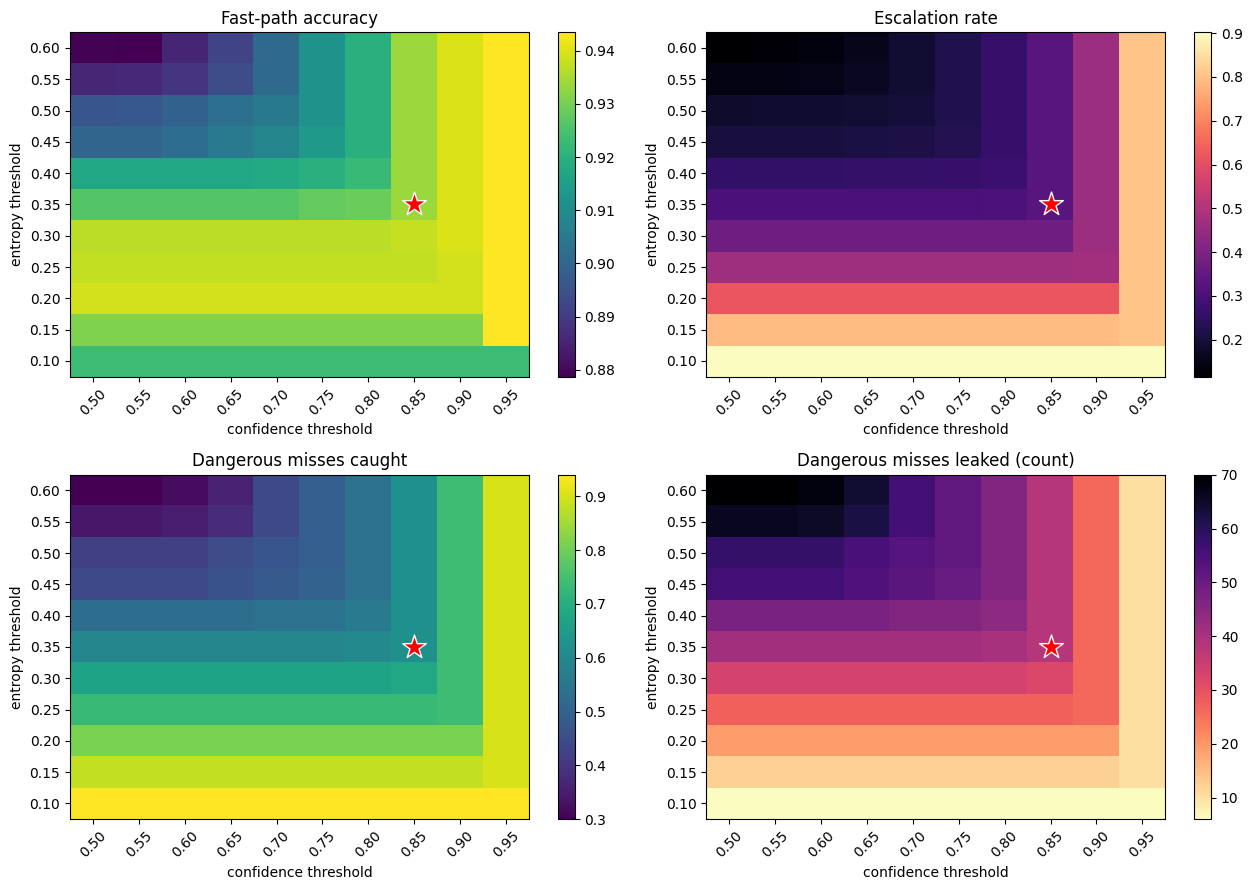

In [15]:

# ================================================== CELL C: sweep heatmaps
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [("fastpath_acc", "Fast-path accuracy", "viridis"),
          ("escalation_rate", "Escalation rate", "magma"),
          ("dang_caught", "Dangerous misses caught", "viridis"),
          ("dang_leaked", "Dangerous misses leaked (count)", "magma_r")]

for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    piv = S.pivot_table(index="entropy_thr", columns="conf_thr", values=col)
    im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"{c:.2f}" for c in piv.columns], rotation=45)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f"{i:.2f}" for i in piv.index])
    ax.set_xlabel("confidence threshold"); ax.set_ylabel("entropy threshold")
    ax.set_title(title)
    ax.scatter([list(piv.columns).index(CONF_THRESHOLD)],
               [list(piv.index).index(ENTROPY_THRESHOLD)],
               marker="*", s=320, c="red", edgecolors="white", zorder=5)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(f"{OUT}/threshold_sweep.png", dpi=140, bbox_inches="tight")
plt.show()
S.to_csv(f"{OUT}/threshold_sweep.csv", index=False)



In [16]:

# ============================== CELL D: verify on TEST with chosen thresholds
acc_t = (ct >= CONF_THRESHOLD) & (et <= ENTROPY_THRESHOLD)
esc_t = ~acc_t

R = {
    "conf_threshold": CONF_THRESHOLD,
    "entropy_threshold": ENTROPY_THRESHOLD,
    "uncertain_floor": UNCERTAIN_FLOOR,
    "temperature": float(TEMP),
    "test_escalation_rate": float(esc_t.mean()),
    "test_fastpath_acc": float((predt[acc_t] == yt[acc_t]).mean()),
    "test_escalated_acc": float((predt[esc_t] == yt[esc_t]).mean()),
    "test_overall_acc": float((predt == yt).mean()),
    "test_dangerous_total": int(dang_t.sum()),
    "test_dangerous_caught": int((dang_t & esc_t).sum()),
    "test_dangerous_leaked": int((dang_t & acc_t).sum()),
    "compute_saving_vs_always_on": float(1 - esc_t.mean()),
}
R["test_dangerous_caught_pct"] = R["test_dangerous_caught"] / max(R["test_dangerous_total"], 1)

print(f"\n{'='*58}\nTEST SET, chosen thresholds\n{'='*58}")
for k, v in R.items():
    print(f"  {k:32s} {v:.4f}" if isinstance(v, float) else f"  {k:32s} {v}")

print(f"\nHeadline for the demo:")
print(f"  {R['test_escalation_rate']:.0%} of images escalate, so "
      f"{R['compute_saving_vs_always_on']:.0%} never touch the transformer.")
print(f"  Of {R['test_dangerous_total']} malignant lesions Layer 1 called benign, "
      f"the gate catches {R['test_dangerous_caught']} "
      f"({R['test_dangerous_caught_pct']:.0%}).")
print(f"  {R['test_dangerous_leaked']} still slip through — report this honestly, "
      f"it is the real residual risk.")




TEST SET, chosen thresholds
  conf_threshold                   0.8500
  entropy_threshold                0.3500
  uncertain_floor                  0.5000
  temperature                      0.9718
  test_escalation_rate             0.2956
  test_fastpath_acc                0.9350
  test_escalated_acc               0.6291
  test_overall_acc                 0.8446
  test_dangerous_total             82
  test_dangerous_caught            52
  test_dangerous_leaked            30
  compute_saving_vs_always_on      0.7044
  test_dangerous_caught_pct        0.6341

Headline for the demo:
  30% of images escalate, so 70% never touch the transformer.
  Of 82 malignant lesions Layer 1 called benign, the gate catches 52 (63%).
  30 still slip through — report this honestly, it is the real residual risk.


In [17]:

# ============================================ CELL E: write thresholds.yaml
yaml_txt = f"""# configs/thresholds.yaml
# Derived from the validation sweep, not asserted. See threshold_sweep.csv/png.
# Layer 1: MobileNetV3-Large (fine-tuned), test acc {MB['test_acc']:.4f}, macro-F1 {MB['test_macro_f1']:.4f}

decision_engine:
  conf_threshold: {CONF_THRESHOLD}
  entropy_threshold: {ENTROPY_THRESHOLD}
  uncertain_floor: {UNCERTAIN_FLOOR}

calibration:
  temperature: {TEMP:.4f}
  applied_to: layer1_logits

classes: {CLASSES}
malignant_classes: {MALIGNANT}

# Measured on the held-out test split with the thresholds above.
measured:
  escalation_rate: {R['test_escalation_rate']:.4f}
  fastpath_accuracy: {R['test_fastpath_acc']:.4f}
  escalated_subset_accuracy: {R['test_escalated_acc']:.4f}
  dangerous_misses_total: {R['test_dangerous_total']}
  dangerous_misses_caught: {R['test_dangerous_caught']}
  dangerous_misses_leaked: {R['test_dangerous_leaked']}
"""
os.makedirs(f"{OUT}/configs", exist_ok=True)
open(f"{OUT}/configs/thresholds.yaml", "w").write(yaml_txt)
json.dump(R, open(f"{OUT}/routing_results.json", "w"), indent=2)
print("\n" + yaml_txt)




# configs/thresholds.yaml
# Derived from the validation sweep, not asserted. See threshold_sweep.csv/png.
# Layer 1: MobileNetV3-Large (fine-tuned), test acc 0.8446, macro-F1 0.7059
 
decision_engine:
  conf_threshold: 0.85
  entropy_threshold: 0.35
  uncertain_floor: 0.5
 
calibration:
  temperature: 0.9718
  applied_to: layer1_logits
 
classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
malignant_classes: ['mel', 'bcc', 'akiec']
 
# Measured on the held-out test split with the thresholds above.
measured:
  escalation_rate: 0.2956
  fastpath_accuracy: 0.9350
  escalated_subset_accuracy: 0.6291
  dangerous_misses_total: 82
  dangerous_misses_caught: 52
  dangerous_misses_leaked: 30



In [18]:

# ================== CELL F: the hard subset for Kashish to train Layer 2 on
hard = pd.DataFrame({
    "image_id": te.image_id.values,
    "true": [CLASSES[i] for i in yt],
    "pred": [CLASSES[i] for i in predt],
    "confidence": ct, "entropy": et,
    "escalated": esc_t, "dangerous_miss": dang_t,
})
hard.to_csv(f"{OUT}/test_routing_detail.csv", index=False)

# Same thing over the TRAIN split — this is the low-confidence subset that
# Layer 2 (RT-DETR) actually gets fine-tuned on, per blueprint Section 7.2.
from torch.utils.data import DataLoader as _DL
dl_tr_eval = _DL(HAM(tr, eval_tf), 64, num_workers=2, pin_memory=True)
Ltr, ytr_ = logits_for(dl_tr_eval)
_, ctr, etr = conf_entropy(Ltr, TEMP)
esc_tr = ~((ctr >= CONF_THRESHOLD) & (etr <= ENTROPY_THRESHOLD))

pd.DataFrame({"image_id": tr.image_id.values, "dx": tr.dx.values,
              "confidence": ctr, "entropy": etr, "escalated": esc_tr}) \
  .to_csv(f"{OUT}/layer2_train_subset.csv", index=False)
print(f"\nLayer 2 training subset: {esc_tr.sum()} / {len(esc_tr)} train images "
      f"({esc_tr.mean():.1%}) fall below the gate -> layer2_train_subset.csv")


Layer 2 training subset: 539 / 7116 train images (7.6%) fall below the gate -> layer2_train_subset.csv


In [19]:
import os, torch
p = f"{OUT}/baseline_mobilenetv3.pt"
print(os.path.exists(p), os.path.getsize(p)/1e6, "MB")
c = torch.load(p, map_location="cpu", weights_only=False)
print(c["metrics"], c["temperature"], c["classes"])

True 17.043061 MB
{'test_acc': 0.8445523941707148, 'test_macro_f1': 0.7059185979930529, 'ece_raw': np.float64(0.02891110046136553), 'ece_cal': np.float64(0.024853892205573883), 'val_macro_f1': 0.7152027986737334, 'temperature': 0.9718133211135864} 0.9718133211135864 ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [20]:
import shutil
shutil.copy(f"{OUT}/baseline_mobilenetv3.pt", f"{OUT}/layer1_mobilenetv3_best.pt")

'/content/drive/MyDrive/amsdds/layer1_mobilenetv3_best.pt'